# Ejercicio Python de Regresión Logística
Realizaremos un ejercicio de prueba para comprender como funciona este algoritmo

In [2]:
import pandas as pd
import numpy as np
from sklearn import linear_model
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Cargamos los datos de entrada del archivo csv

In [3]:
dataframe = pd.read_csv("data/usuarios_win_mac_lin.csv")

clases = {
    0: 'Windows',
    1: 'Linux',
    2: 'Mac'
}

dataframe.head()

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


In [7]:
dataframe['clase'].value_counts(normalize = True)

clase
0    0.505882
2    0.258824
1    0.235294
Name: proportion, dtype: float64

In [8]:
dataframe.describe()

,duracion,paginas,acciones,valor,clase
count,170.000000,170.000000,170.000000,170.000000,170.000000
mean,111.075729,2.041176,8.723529,32.676471,0.752941
std,202.453200,1.500911,9.136054,44.751993,0.841327
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,11.000000,1.000000,3.000000,8.000000,0.000000
50%,13.000000,2.000000,6.000000,20.000000,0.000000
75%,108.000000,2.000000,10.000000,36.000000,2.000000
max,898.000000,9.000000,63.000000,378.000000,2.000000


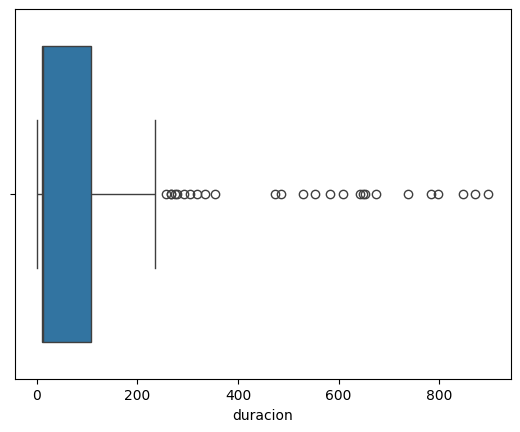

In [9]:
sns.boxplot(x= dataframe['duracion']);

In [10]:
dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duracion  170 non-null    float64
 1   paginas   170 non-null    int64  
 2   acciones  170 non-null    int64  
 3   valor     170 non-null    int64  
 4   clase     170 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 6.8 KB


In [11]:
print(dataframe.groupby('clase').size())

clase
0    86
1    40
2    44
dtype: int64


## Visualizamos los datos

In [12]:
dataframe.drop(columns=['clase'])

,duracion,paginas,acciones,valor
0,7.0,2,4,8
1,21.0,2,6,6
2,57.0,2,4,4
3,101.0,3,6,12
4,109.0,2,6,12
...,...,...,...,...
165,13.0,1,7,42
166,12.0,1,2,6
167,13.0,1,3,9
168,13.0,1,7,28


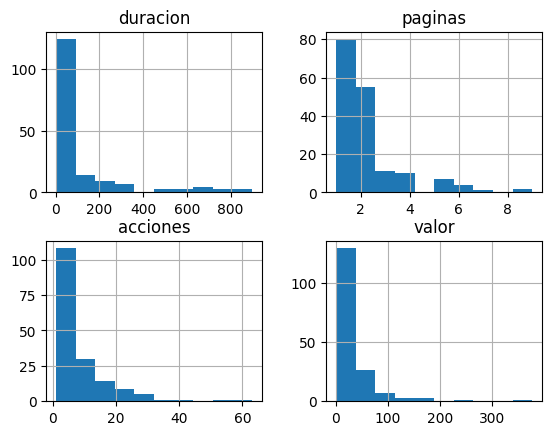

In [13]:
dataframe.drop(columns=['clase']).hist()
plt.show()

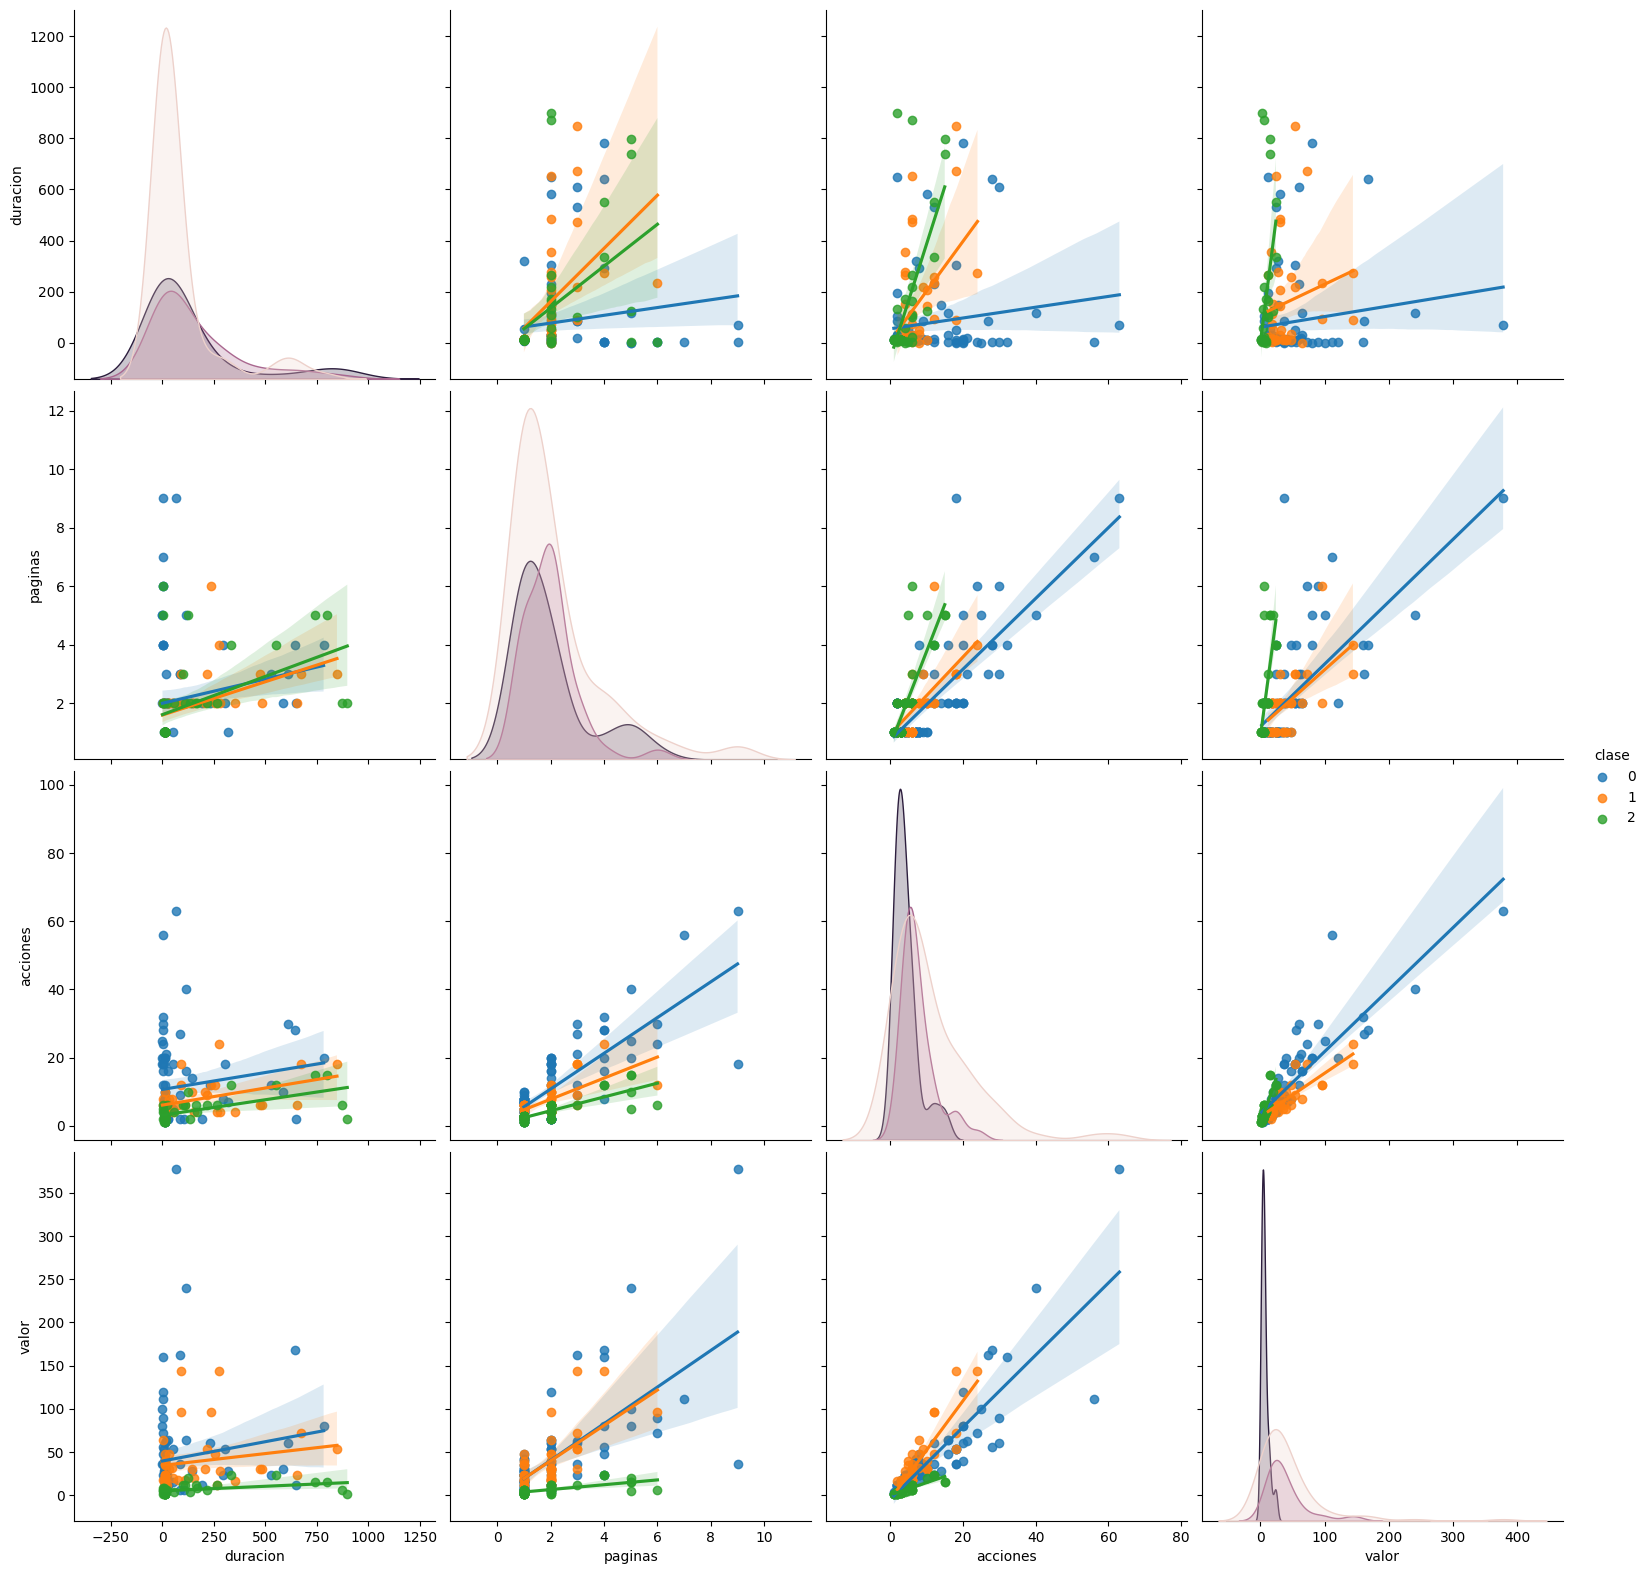

In [14]:
sns.pairplot(dataframe.dropna(),
            hue='clase',
            height=4,
            vars=["duracion", "paginas","acciones","valor"],
            kind='reg'); # "reg" de regresión lineal

## Creamos el modelo

In [15]:
X = np.array(dataframe.drop(columns=['clase']))
y = np.array(dataframe['clase'])

In [16]:
from sklearn.linear_model import LogisticRegression

In [17]:
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [18]:
predictions = model.predict(X)
print(predictions)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 1 0 1 0 1 1 0 1 1 1 1 1 1 0 2 2
 2 2 2 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 1 0 0 0 0 2 0
 0 1 1 1 0 0 0 0 0 0 0 0 2 1 0 0 0 0 1 0 0 2 0 2 1 0 0 0 0 0 0 0 0 0 0 1 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0
 0 0 0 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 0]


In [19]:
predicions_proba = model.predict_proba(X)
print(np.round(np.array(predicions_proba), 2))

[[0.22 0.09 0.69]
 [0.   0.   1.  ]
 [0.   0.   1.  ]
 [0.18 0.08 0.74]
 [0.28 0.1  0.62]
 [0.27 0.08 0.65]
 [0.05 0.05 0.91]
 [0.22 0.09 0.69]
 [0.09 0.06 0.84]
 [0.   0.   1.  ]
 [0.12 0.07 0.8 ]
 [0.32 0.09 0.59]
 [0.1  0.06 0.84]
 [0.   0.   1.  ]
 [0.   0.   1.  ]
 [0.23 0.09 0.68]
 [0.   0.   1.  ]
 [0.65 0.34 0.01]
 [0.58 0.42 0.  ]
 [0.73 0.27 0.  ]
 [0.71 0.29 0.  ]
 [0.32 0.68 0.  ]
 [0.82 0.18 0.  ]
 [0.46 0.54 0.  ]
 [0.78 0.22 0.  ]
 [0.37 0.63 0.  ]
 [0.09 0.91 0.  ]
 [0.72 0.28 0.  ]
 [0.45 0.52 0.03]
 [0.5  0.5  0.  ]
 [0.35 0.65 0.  ]
 [0.22 0.78 0.  ]
 [0.26 0.74 0.  ]
 [0.22 0.78 0.  ]
 [0.64 0.36 0.  ]
 [0.01 0.   0.99]
 [0.03 0.02 0.95]
 [0.   0.   1.  ]
 [0.   0.   1.  ]
 [0.   0.   1.  ]
 [0.81 0.19 0.  ]
 [0.61 0.39 0.  ]
 [0.54 0.46 0.  ]
 [0.23 0.77 0.  ]
 [0.68 0.32 0.  ]
 [0.28 0.72 0.  ]
 [0.57 0.43 0.  ]
 [0.41 0.59 0.  ]
 [0.76 0.24 0.  ]
 [0.99 0.01 0.  ]
 [0.77 0.23 0.  ]
 [0.78 0.22 0.  ]
 [0.97 0.03 0.  ]
 [0.99 0.01 0.  ]
 [0.91 0.09 0.  ]
 [0.98 0.0

In [20]:
model.score(X, y)

0.7764705882352941

In [21]:
model.classes_

array([0, 1, 2])

# Validación del Modelo

In [18]:
validation_size = 0.20
seed = 7
X_train, X_test, Y_train, Y_test = model_selection.train_test_split(X,
                                                                    y,
                                                                    test_size=validation_size,
                                                                    random_state=seed)

In [19]:
name='Logistic Regression'
kfold = model_selection.KFold(n_splits=10) #Parte los datos en 10 trozos para usar validación cruzada / cross validation
cv_results = model_selection.cross_val_score(model, X_train, Y_train, cv=kfold, scoring='accuracy')

msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
print(cv_results)
print(msg)

[0.78571429 0.64285714 0.71428571 0.71428571 0.71428571 0.71428571
 0.84615385 0.92307692 0.61538462 0.61538462]
Logistic Regression: 0.728571 (0.094186)


In [20]:
from sklearn.model_selection import GridSearchCV

params = {"C" : np.arange(0.1,10,0.1)}

gs = GridSearchCV(estimator=model, param_grid=params, cv=3, scoring='accuracy', verbose=3)
gs.fit(X_train, Y_train)

print(gs.best_estimator_)
print(gs.best_score_)
print(gs.best_params_)

Fitting 3 folds for each of 99 candidates, totalling 297 fits
[CV 1/3] END .............................C=0.1;, score=0.674 total time=   0.0s
[CV 2/3] END .............................C=0.1;, score=0.711 total time=   0.0s
[CV 3/3] END .............................C=0.1;, score=0.711 total time=   0.0s
[CV 1/3] END .............................C=0.2;, score=0.717 total time=   0.0s
[CV 2/3] END .............................C=0.2;, score=0.711 total time=   0.0s
[CV 3/3] END .............................C=0.2;, score=0.711 total time=   0.0s
[CV 1/3] END .............C=0.30000000000000004;, score=0.717 total time=   0.0s
[CV 2/3] END .............C=0.30000000000000004;, score=0.756 total time=   0.0s
[CV 3/3] END .............C=0.30000000000000004;, score=0.711 total time=   0.0s
[CV 1/3] END .............................C=0.4;, score=0.696 total time=   0.0s
[CV 2/3] END .............................C=0.4;, score=0.756 total time=   0.0s
[CV 3/3] END .............................C=0.4

c:\Users\Alberto Romero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[CV 1/3] END .............................C=2.7;, score=0.717 total time=   0.1s
[CV 2/3] END .............................C=2.7;, score=0.756 total time=   0.0s
[CV 3/3] END .............................C=2.7;, score=0.711 total time=   0.0s
[CV 1/3] END ..............C=2.8000000000000003;, score=0.717 total time=   0.0s
[CV 2/3] END ..............C=2.8000000000000003;, score=0.756 total time=   0.1s
[CV 3/3] END ..............C=2.8000000000000003;, score=0.711 total time=   0.0s
[CV 1/3] END ..............C=2.9000000000000004;, score=0.717 total time=   0.0s
[CV 2/3] END ..............C=2.9000000000000004;, score=0.756 total time=   0.0s
[CV 3/3] END ..............C=2.9000000000000004;, score=0.711 total time=   0.0s
[CV 1/3] END ..............C=3.0000000000000004;, score=0.717 total time=   0.0s
[CV 2/3] END ..............C=3.0000000000000004;, score=0.756 total time=   0.0s
[CV 3/3] END ..............C=3.0000000000000004;, score=0.711 total time=   0.0s
[CV 1/3] END ...............

c:\Users\Alberto Romero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[CV 1/3] END .............................C=5.4;, score=0.717 total time=   0.1s
[CV 2/3] END .............................C=5.4;, score=0.756 total time=   0.0s
[CV 3/3] END .............................C=5.4;, score=0.711 total time=   0.0s
[CV 1/3] END .............................C=5.5;, score=0.717 total time=   0.0s
[CV 2/3] END .............................C=5.5;, score=0.756 total time=   0.0s
[CV 3/3] END .............................C=5.5;, score=0.711 total time=   0.0s
[CV 1/3] END .............................C=5.6;, score=0.717 total time=   0.1s
[CV 2/3] END .............................C=5.6;, score=0.756 total time=   0.0s
[CV 3/3] END .............................C=5.6;, score=0.711 total time=   0.0s
[CV 1/3] END .............................C=5.7;, score=0.717 total time=   0.1s
[CV 2/3] END .............................C=5.7;, score=0.756 total time=   0.0s
[CV 3/3] END .............................C=5.7;, score=0.711 total time=   0.0s
[CV 1/3] END ...............

c:\Users\Alberto Romero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[CV 1/3] END .............................C=7.4;, score=0.717 total time=   0.1s
[CV 2/3] END .............................C=7.4;, score=0.778 total time=   0.0s
[CV 3/3] END .............................C=7.4;, score=0.711 total time=   0.0s
[CV 1/3] END .............................C=7.5;, score=0.717 total time=   0.1s
[CV 2/3] END .............................C=7.5;, score=0.778 total time=   0.1s
[CV 3/3] END .............................C=7.5;, score=0.711 total time=   0.1s
[CV 1/3] END .............................C=7.6;, score=0.717 total time=   0.1s
[CV 2/3] END .............................C=7.6;, score=0.778 total time=   0.0s
[CV 3/3] END .............................C=7.6;, score=0.711 total time=   0.0s
[CV 1/3] END .............................C=7.7;, score=0.717 total time=   0.1s
[CV 2/3] END .............................C=7.7;, score=0.778 total time=   0.0s
[CV 3/3] END .............................C=7.7;, score=0.711 total time=   0.0s
[CV 1/3] END ...............

In [21]:
# model = gs.best_estimator_ 
model = LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)

LogisticRegression(max_iter=1000)

In [22]:
predictions = model.predict(X_test)
print(accuracy_score(Y_test, predictions))

0.8529411764705882


In [23]:
acierto = accuracy_score(Y_test, predictions)

error = 1 - acierto
print("Acierto:", round(acierto*100, 2), "%")
print("Error:", round(error*100, 2), "%")

Acierto: 85.29 %
Error: 14.71 %


## Resultados

In [24]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [25]:
c_matrix = confusion_matrix(Y_test, predictions)

In [26]:
print(c_matrix)

[[16  0  2]
 [ 3  3  0]
 [ 0  0 10]]


In [27]:
(16+3+10)/(16+3+10 +2+3)

0.8529411764705882

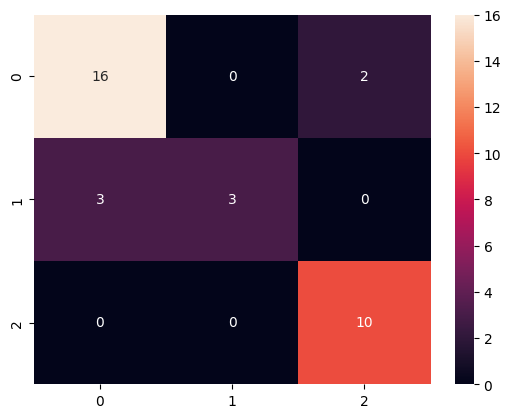

In [28]:
import seaborn as sns
sns.heatmap(c_matrix, annot=True);

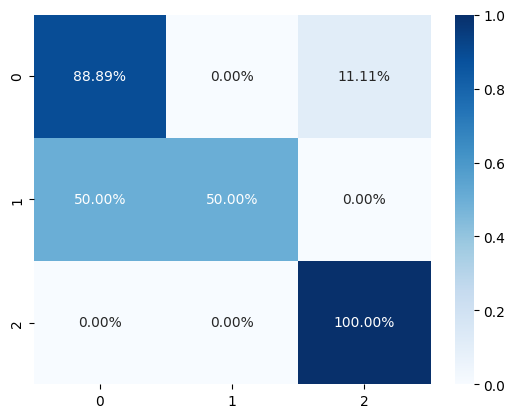

In [29]:
sns.heatmap(confusion_matrix(Y_test, predictions, normalize='true'), annot=True, 
            fmt='.2%', cmap='Blues');

In [30]:
from sklearn.metrics import multilabel_confusion_matrix, precision_score, recall_score, f1_score

multilabel_confusion_matrix(Y_test, predictions)

array([[[13,  3],
        [ 2, 16]],

       [[28,  0],
        [ 3,  3]],

       [[22,  2],
        [ 0, 10]]])

[Nice confusion matrix catalog visuals examples](https://medium.com/@dtuk81/confusion-matrix-visualization-fc31e3f30fea)

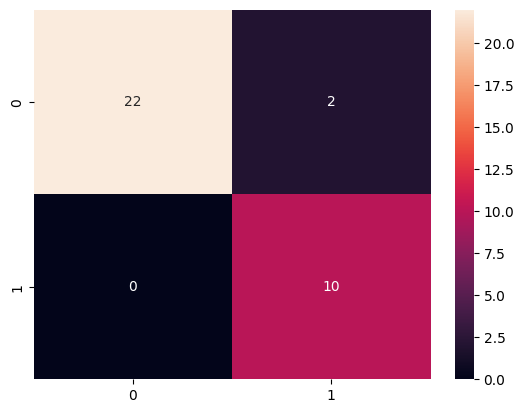

In [31]:
sns.heatmap(multilabel_confusion_matrix(Y_test, predictions)[2], annot=True);

In [32]:
multilabel_confusion_matrix(Y_test, predictions)

array([[[13,  3],
        [ 2, 16]],

       [[28,  0],
        [ 3,  3]],

       [[22,  2],
        [ 0, 10]]])

In [33]:
10 / (0  + 10)

1.0

In [34]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, predictions))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86        18
           1       1.00      0.50      0.67         6
           2       0.83      1.00      0.91        10

    accuracy                           0.85        34
   macro avg       0.89      0.80      0.81        34
weighted avg       0.87      0.85      0.84        34



In [35]:
from sklearn.metrics import recall_score, precision_score

print("recall", recall_score(Y_test, predictions, average='macro'))
print("precision", precision_score(Y_test, predictions, average='macro'))


recall 0.7962962962962963
precision 0.8918128654970761


In [36]:
print("recall", recall_score(Y_test, predictions, average='weighted'))
print("precision", precision_score(Y_test, predictions, average='weighted'))

recall 0.8529411764705882
precision 0.8673890608875129


# Clasificación de nuevos registros

In [37]:
X_new = pd.DataFrame({'duracion': [8],
                     'paginas': [5],
                     'acciones': [5],
                     'valor': [2]})
X_new

,duracion,paginas,acciones,valor
0,8,5,5,2


In [38]:
X_new.values

array([[8, 5, 5, 2]])

In [39]:
model.predict(X_new.values)

array([2])

In [40]:
np.round(model.predict_proba(X_new.values))

array([[0., 0., 1.]])